<a href="https://colab.research.google.com/github/ayishaarif6-gif/Supervised-machine-learning/blob/main/XG_Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [ ]:
data = pd.read_csv('/content/employee_performance_workload_attrition.csv')
data.head()

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,1,HR,Junior,81750,55,1,1,17,1,Yes
1,2,Engineering,Senior,58140,36,2,4,13,1,Yes
2,3,Finance,Mid,37747,61,2,2,20,5,No
3,4,Finance,Senior,81993,36,4,1,17,2,Yes
4,5,Sales,Senior,45439,53,5,5,5,1,No


In [ ]:
data.shape

(2800, 10)

In [ ]:
data.isnull().sum()

,0
employee_id,0
department,0
role_level,0
monthly_salary,0
avg_weekly_hours,0
projects_handled,0
performance_rating,0
absences_days,0
job_satisfaction,0
attrition,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,employee_id,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,74492.075000,49.842500,4.519286,2.960714,9.995000,2.995357
std,808.434702,25899.209391,8.980976,2.286778,1.404794,6.056656,1.414332
min,1.000000,30006.000000,35.000000,1.000000,1.000000,0.000000,1.000000
25%,700.750000,51665.000000,42.000000,3.000000,2.000000,5.000000,2.000000
50%,1400.500000,74587.500000,50.000000,4.000000,3.000000,10.000000,3.000000
75%,2100.250000,97249.500000,57.000000,7.000000,4.000000,15.000000,4.000000
max,2800.000000,119977.000000,65.000000,8.000000,5.000000,20.000000,5.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         2800 non-null   int64 
 1   department          2800 non-null   object
 2   role_level          2800 non-null   object
 3   monthly_salary      2800 non-null   int64 
 4   avg_weekly_hours    2800 non-null   int64 
 5   projects_handled    2800 non-null   int64 
 6   performance_rating  2800 non-null   int64 
 7   absences_days       2800 non-null   int64 
 8   job_satisfaction    2800 non-null   int64 
 9   attrition           2800 non-null   object
dtypes: int64(7), object(3)
memory usage: 218.9+ KB


In [ ]:
data = data.drop('employee_id', axis=1)

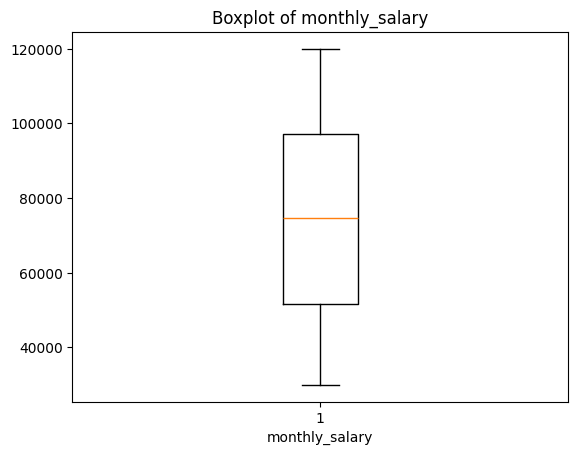

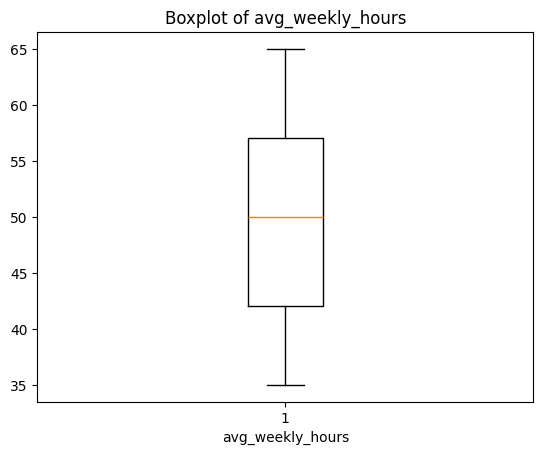

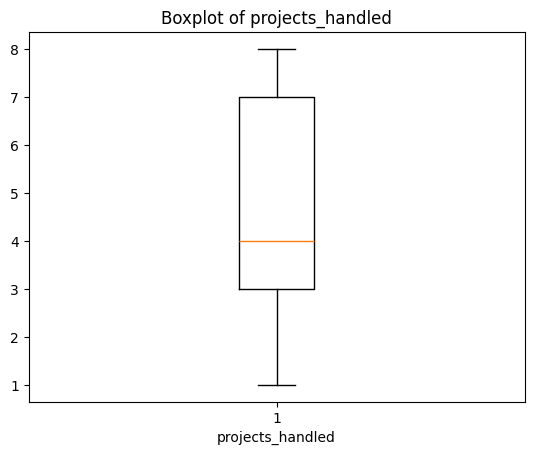

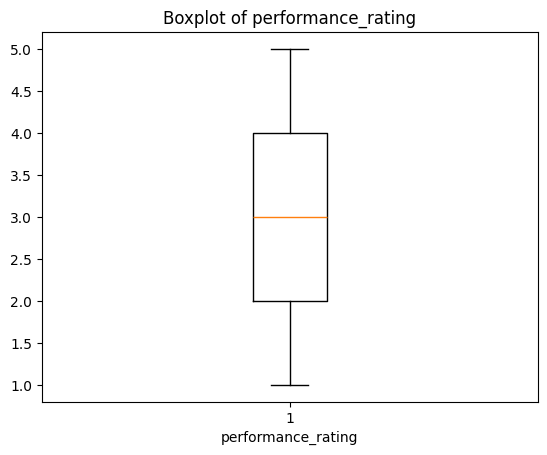

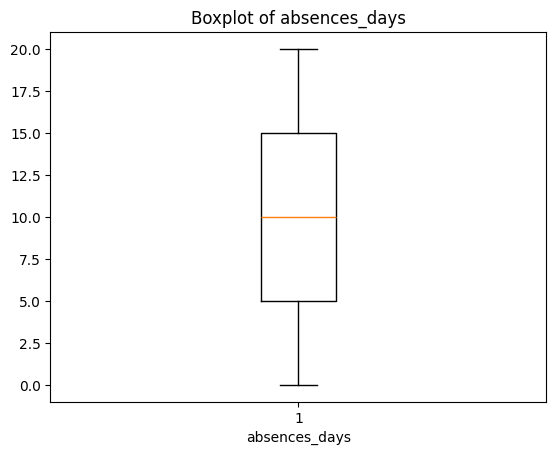

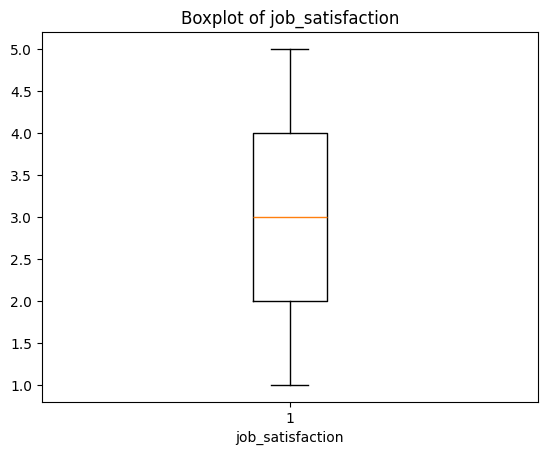

In [ ]:
num_col = data.select_dtypes(include='number').columns
for col in num_col:
   plt.figure()
   plt.boxplot(data[col].dropna())
   plt.title(f'Boxplot of {col}')
   plt.xlabel(col)
   plt.show()

In [ ]:
data['attrition'].value_counts()

,count
attrition,
No,1660
Yes,1140


In [ ]:
nominal_col = ['department','attrition']
data = pd.get_dummies(data, columns=nominal_col, drop_first=True)

In [ ]:
le = LabelEncoder()
data['role_level'] = le.fit_transform(data['role_level'])

In [ ]:
data.dtypes

,0
role_level,int64
monthly_salary,int64
avg_weekly_hours,int64
projects_handled,int64
performance_rating,int64
absences_days,int64
job_satisfaction,int64
department_Finance,bool
department_HR,bool
department_Marketing,bool


In [ ]:
X = data.drop('attrition_Yes', axis=1)
y = data['attrition_Yes']

In [ ]:
print(X.shape)
print(y.shape)

(2800, 12)
(2800,)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X_scaled , y , test_size=0.2 , random_state=42)

In [ ]:
model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    scale_pos_weight = 1,
    eval_metric='auc'
)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:19:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
y_pred = (y_prob >= 0.28).astype(int)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:",cm)

Confusion Matrix: [[164 169]
 [ 55 172]]


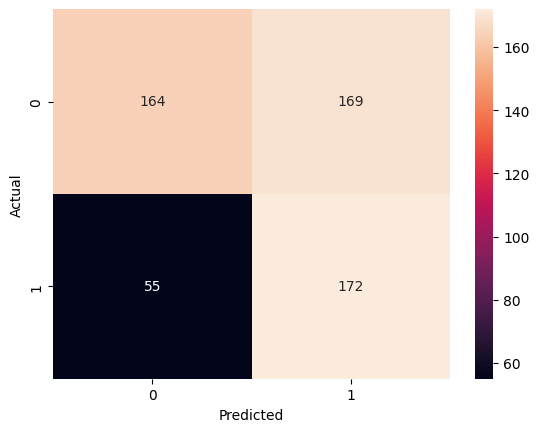

In [ ]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.75      0.49      0.59       333
        True       0.50      0.76      0.61       227

    accuracy                           0.60       560
   macro avg       0.63      0.63      0.60       560
weighted avg       0.65      0.60      0.60       560

